<a href="https://colab.research.google.com/github/anuragpatil811/Machine-Learning/blob/main/Lab_ESE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('/content/diabetes.csv')

In [ ]:
df.head(3)

,glucose,bloodpressure,diabetes
0,40,85,0
1,40,92,0
2,45,63,1


In [ ]:
df.isnull().sum()

,0
glucose,0
bloodpressure,0
diabetes,0


In [ ]:
df.duplicated().sum()

np.int64(820)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
import seaborn as sns

<Axes: ylabel='glucose'>

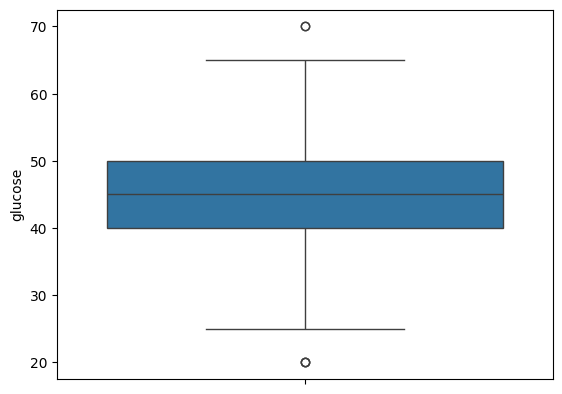

In [ ]:
sns.boxplot(data=df, y="glucose")

In [ ]:
df["glucose"].describe()

,glucose
count,175.000000
mean,44.485714
std,10.367864
min,20.000000
25%,40.000000
50%,45.000000
75%,50.000000
max,70.000000


In [ ]:
q1 = 40.0
q3 = 50.0
IQR = q3 - q1

In [ ]:
ub = q3 + 1.5*IQR
lb = q1 - 1.5*IQR

In [ ]:
df = df[(df["glucose"]>lb)&(df["glucose"]<ub)]

<Axes: ylabel='glucose'>

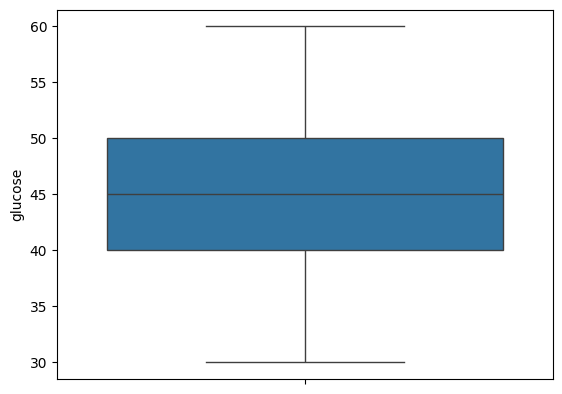

In [ ]:
sns.boxplot(data=df, y="glucose")

In [ ]:
x = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
#Bagging Technique: Random Forest Classifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_predict1 = rf.predict(X_test)
y_predict1

array([1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1])

In [30]:
from sklearn.metrics import r2_score, mean_squared_error
r2_score(y_test, y_predict1)



-0.3090909090909091

In [31]:
mean_squared_error(y_test, y_predict1)

0.28125

In [ ]:
#Training Score
rf.score(X_train, y_train)

0.8548387096774194

In [ ]:
#Testing Score
rf.score(X_test, y_test)

0.71875

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_predict2 = xgb.predict(X_test)
y_predict2

array([1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0])

In [ ]:
#Training score
xgb.score(X_train, y_train)

0.8467741935483871

In [ ]:
#Testing Score
xgb.score(X_test, y_test)

0.8125

In [32]:
r2_score(y_test, y_predict2)

0.12727272727272732

In [33]:
mean_squared_error(y_test, y_predict2)

0.1875